# Garmin "Wrapped"

I purchased my Garmin Forerunner 265 on 12/1/24, and have been logging workouts daily since then.

Recently, I discovered that Garmin allows you to easily export activities on a rolling six month window.

While the watch provides basic insights on a week-to-week basis, I wanted to dive a little deeper into how my habits have changed. I've slowly shifted away from climbing as the weather on the East Coast has started to get warmer, and been on a 4-5 day lifting schedule.

In [53]:
!pip3 install --force-reinstall "numpy<2.0"
!pip3 install pandas matplotlib seaborn


DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
  Using cached numpy-1.26.4-cp39-cp39-macosx_10_9_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp39-cp39-macosx_10_9_x86_64.whl (20.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, 

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Setting up colors for graphs

COLORS = {
	'Running':           '#f97316',
	'Treadmill Running': '#fb923c',
	'Bouldering':        '#a78bfa',
	'Strength Training': '#34d399',
	'Yoga':              '#60a5fa', # Stretching
	'Hiking':            '#fbbf24',
	'Other':             '#9ca3af',
}

In [5]:
df_raw = pd.read_csv("activities.csv")

# Parsing helpers
def parse_duration(s):
	if pd.isna(s) or s == '--':
		return np.nan
	s = str(s).strip()
	p = s.split(":")
	try:
		if len(p) == 3:
			return int(p[0])*3600 + int(p[1])*60 + float(p[2])
		elif len(p) == 2:
			return int(p[0])*60 + float(p[1])
		else:
			return float(p[0])
	except IndexError:
		return np.nan

def clean(s):
	if pd.isna(s) or str(s).strip() in ('--', ''):
		return np.nan
	return pd.to_numeric(str(s).replace(',', ''), errors='coerce')

In [8]:
# Some janitor/plumbing work:

df = df_raw.copy()
df['Date'] = pd.to_datetime(df['Date'])
df['date_only'] = df['Date'].dt.date
df['weekday'] = df['Date'].dt.day_name()
df['weekday_num'] = df['Date'].dt.dayofweek  # 0=Mon ... 6=Sun
df['hour'] = df['Date'].dt.hour
df['week'] = df['Date'].dt.to_period('W')
df['month'] = df['Date'].dt.to_period('M')
df['month_label'] = df['Date'].dt.strftime('%b %Y')

# Duration in minutes
df['duration_sec'] = df['Time'].apply(parse_duration)
df['duration_min'] = df['duration_sec'] / 60

for col in ['Calories', 'Avg HR', 'Max HR', 'Aerobic TE', 'Distance',
			'Total Reps', 'Total Sets', 'Total Routes']:
	df[col] = df[col].apply(clean)

# Specifics for bouldering
df['climb_time_sec'] = df['Climb Time'].apply(parse_duration)
df['rest_sec'] = df['Total Rest'].apply(parse_duration)
df['climb_ratio'] = df['climb_time_sec'] / df['duration_sec']

df['pace_sec_mi'] = df['Avg Pace'].apply(parse_duration)

# Tidy activity type labels
def simplify(t):
	if 'Running' in str(t):
		return t  # keep Treadmill vs Outdoor
	return t

df['activity_group'] = df['Activity Type'].apply(
	lambda x: x if x in COLORS else 'Other'
)

In [9]:
print(f'Loaded {len(df)} activities from {df["Date"].min().date()} to {df["Date"].max().date()}')
df[['Date','Activity Type','duration_min','Calories','Avg HR']].head(8)

Loaded 160 activities from 2025-10-12 to 2026-03-21


,Date,Activity Type,duration_min,Calories,Avg HR
0,2026-03-21 09:19:08,Running,43.650000,487,143.0
1,2026-03-20 07:42:13,Strength Training,32.000000,156,99.0
2,2026-03-19 19:04:26,Bouldering,98.866667,510,107.0
3,2026-03-19 07:11:47,Strength Training,43.983333,226,102.0
4,2026-03-17 19:29:08,Treadmill Running,41.916667,508,149.0
5,2026-03-17 06:53:49,Strength Training,69.900000,346,103.0
6,2026-03-16 07:11:29,Strength Training,60.783333,352,108.0
7,2026-03-13 17:42:40,Strength Training,18.600000,133,116.0


### High Level Breakdown

Total hours: 154.2 hours
Total calories: 60,868 kcal
Average Workouts/Week*: 7.0 sessions


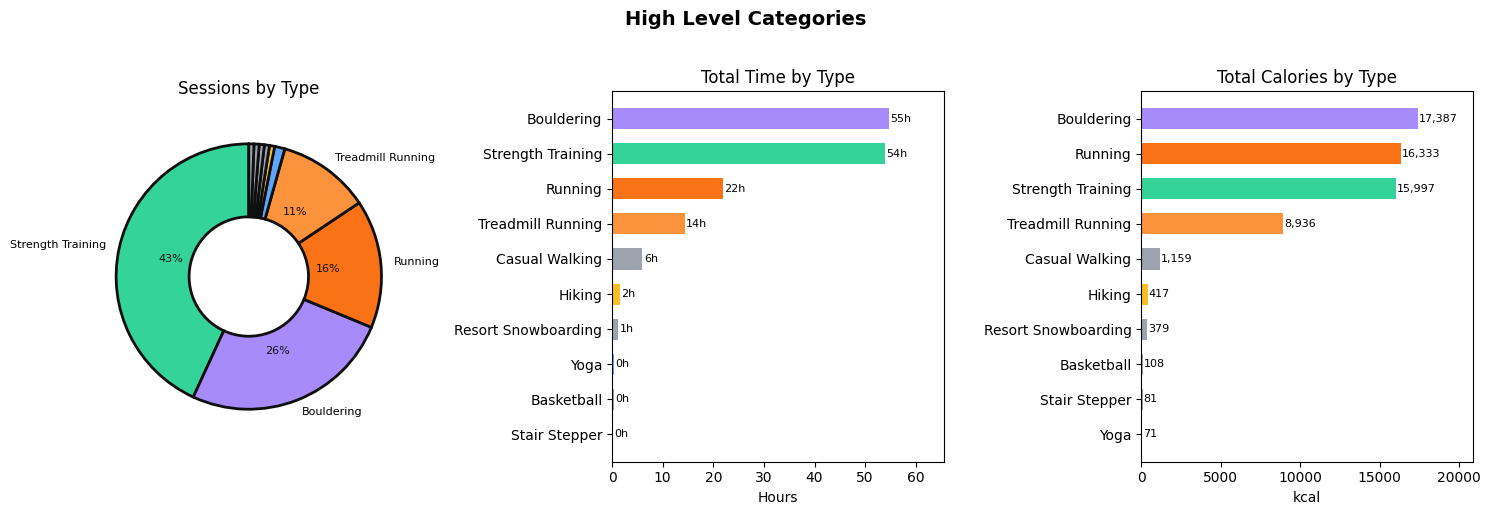

In [73]:
counts = df['Activity Type'].value_counts()
total_hours = df['duration_min'].sum() / 60
total_cals = df['Calories'].sum()
days_span = (df['Date'].max() - df['Date'].min()).days

print(f"Total hours: {total_hours:.1f} hours")
print(f"Total calories: {total_cals:,.0f} kcal")
# There's some noise here due to separate session tracking for
# stretching (under yoga) after each lift during my lift sessions.
# It seems like too much work to clean this up, so this value is slightly inflated.
print(f"Average Workouts/Week*: {len(df)/(days_span/7):.1f} sessions")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('High Level Categories', fontsize=14, fontweight='bold', y=1.02)

total = counts.sum()
pcts = counts.values / total

def autopct(v):
	return '%1.0f%%' % v if v / 100 >= 0.02 else ''

ax = axes[0]
c_map = [COLORS.get(k, '#9ca3af') for k in counts.index]
# Hide the activities in the donut chart under 2%
# to avoid overlapping labels on the top half of the chart.
labels = [l if p >= 0.02 else '' for l, p in zip(counts.index, pcts)]
wedges, texts, autotexts = ax.pie(
	counts.values, labels=labels, autopct=autopct,
	colors=c_map, startangle=90,
	wedgeprops=dict(width=0.55, edgecolor='#0f0f0f', linewidth=2),
	textprops=dict(fontsize=8)
)
for at in autotexts:
	at.set_color('#111')
ax.set_title('Sessions by Type', pad=12)

ax = axes[1]
hrs = df.groupby('Activity Type')['duration_min'].sum().sort_values() / 60
colors2 = [COLORS.get(k, '#9ca3af') for k in hrs.index]
bars = ax.barh(hrs.index, hrs.values, color=colors2, height=0.6)
for bar, val in zip(bars, hrs.values):
	ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
			f'{val:.0f}h', va='center', fontsize=8)
ax.set_xlabel('Hours')
ax.set_title('Total Time by Type')
ax.set_xlim(0, hrs.max()*1.2)

ax = axes[2]
cal = df.groupby('Activity Type')['Calories'].sum().sort_values()
colors3 = [COLORS.get(k, '#9ca3af') for k in cal.index]
bars = ax.barh(cal.index, cal.values, color=colors3, height=0.6)
for bar, val in zip(bars, cal.values):
	ax.text(val + 50, bar.get_y() + bar.get_height()/2,
			f'{val:,.0f}', va='center', fontsize=8)
ax.set_xlabel('kcal')
ax.set_title('Total Calories by Type')
ax.set_xlim(0, cal.max()*1.2)

plt.tight_layout()
plt.show()

\* I had a period where I used to stretch after every lifting workout, which I consider to be in the same workout. Combining these workouts together seems to be a larger lift that I am willing to do.

Longest streak: 13 days


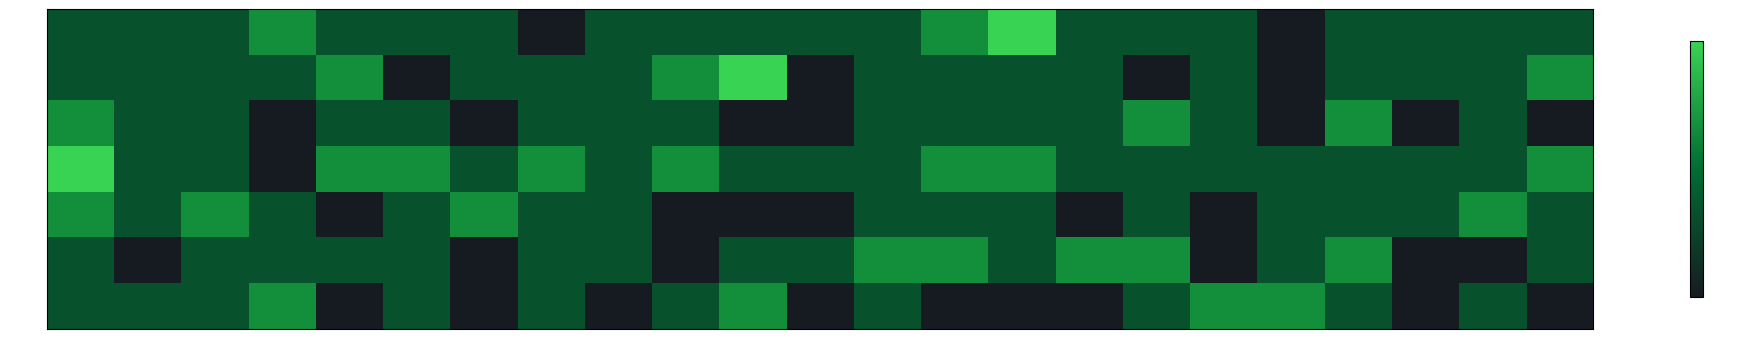

In [47]:
import matplotlib.colors as mcolors

active_days = sorted(df['date_only'].unique())
active_set = set(active_days)

def compute_streaks(day_list):
	if not day_list:
		return []
	streaks, streak_start, prev = [], day_list[0], day_list[0]
	for d in day_list[1:]:
		if (d - prev).days == 1:
			prev = d
		else:
			streaks.append((streak_start, prev, (prev - streak_start).days + 1))
			streak_start = prev = d
	streaks.append((streak_start, prev, (prev - streak_start).days + 1))
	return streaks

all_streaks = compute_streaks(active_days)
longest = max(all_streaks, key=lambda x: x[2])

print(f"Longest streak: {longest[2]} days")

date_range = pd.date_range(df['Date'].min().date(), df['Date'].max().date())
cal_df = pd.DataFrame({'date': date_range})
counts_per_day = df.groupby('date_only').size().reset_index(name='n')
counts_per_day['date_only'] = pd.to_datetime(counts_per_day['date_only'])
cal_df = cal_df.merge(counts_per_day, left_on='date', right_on='date_only', how='left').fillna(0)
cal_df['week_num'] = (cal_df['date'] - cal_df['date'].min()).dt.days // 7
cal_df['dow'] = cal_df['date'].dt.dayofweek

pivot = cal_df.pivot_table(index='dow', columns='week_num', values='n', aggfunc='sum').fillna(0)

cmap = mcolors.LinearSegmentedColormap.from_list('gh_greens', ['#161b22', '#006d32', '#39d353'])

with plt.rc_context({'axes.facecolor': plt.rcParams['figure.facecolor'], 'figure.facecolor': plt.rcParams['figure.facecolor'],
					 'text.color': 'white', 'axes.labelcolor': 'white',
					 'xtick.color': 'white', 'ytick.color': 'white'}):
	fig, ax = plt.subplots(figsize=(20, 3.5))
	im = ax.imshow(pivot.values, aspect='auto', cmap=cmap, vmin=0, vmax=3,
				   interpolation='nearest')
	ax.set_yticks(range(7))
	ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], fontsize=9)
	ax.set_xticks([])
	cb = plt.colorbar(im, ax=ax, label='sessions/day', shrink=0.8)
	cb.ax.yaxis.label.set_color('white')
	plt.tight_layout()
	plt.show()

### Workout Duration

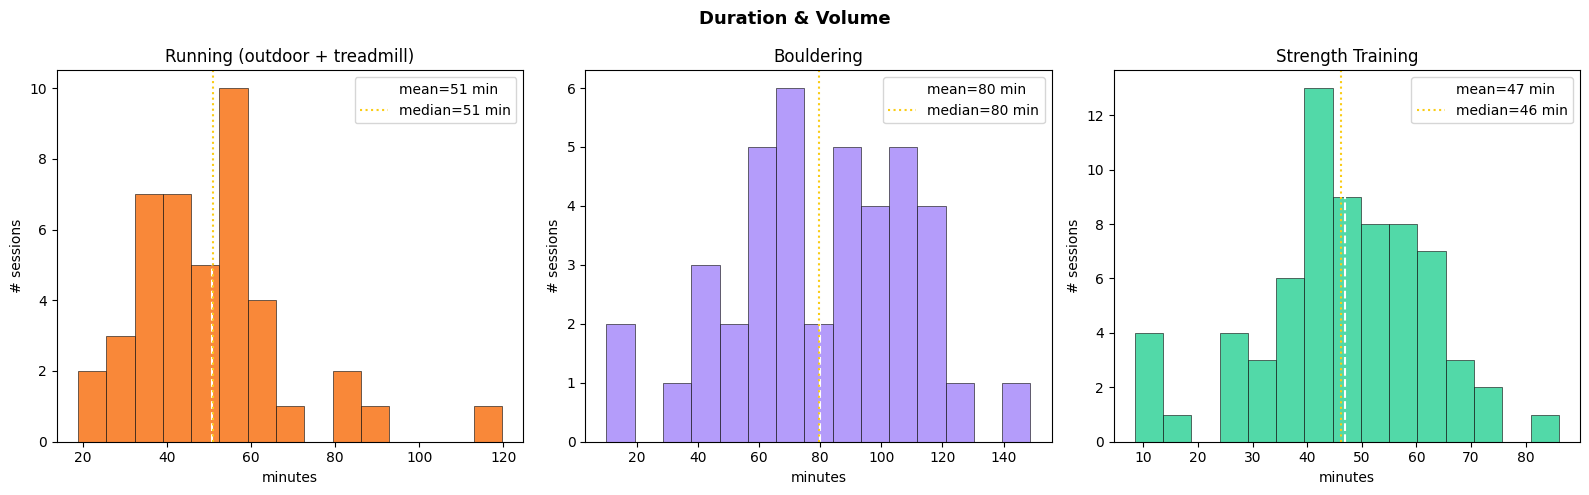

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Duration & Volume', fontsize=13, fontweight='bold')

for ax, atype, label in zip(
	axes,
	['Running', 'Bouldering', 'Strength Training'],
	['Running (outdoor + treadmill)', 'Bouldering', 'Strength Training']
):
	if atype == 'Running':
		sub = df[df['Activity Type'].str.contains('Running')]['duration_min'].dropna()
		color = COLORS['Running']
	else:
		sub = df[df['Activity Type'] == atype]['duration_min'].dropna()
		color = COLORS[atype]

	ax.hist(sub, bins=15, color=color, alpha=0.85, edgecolor='#0f0f0f', linewidth=0.5)
	ax.axvline(sub.mean(), color='white', lw=1.5, linestyle='--', label=f'mean={sub.mean():.0f} min')
	ax.axvline(sub.median(), color='#facc15', lw=1.5, linestyle=':', label=f'median={sub.median():.0f} min')
	ax.set_xlabel('minutes')
	ax.set_ylabel('# sessions')
	ax.set_title(label)
	ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

dur_summary = df.groupby('Activity Type')['duration_min'].agg(['mean','median','min','max','count'])
dur_summary.columns = ['Mean (min)','Median (min)','Min (min)','Max (min)','Sessions']
dur_summary = dur_summary.round(1)

### Heart Rate / Intensity

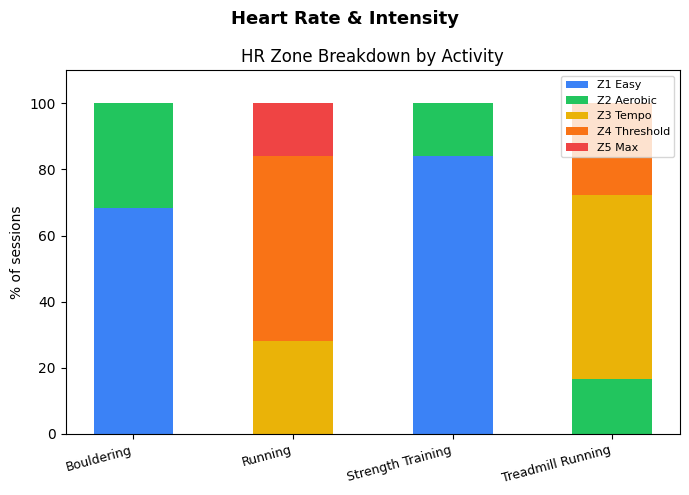

In [61]:
hr_df = df[df['Avg HR'].notna() & (df['Avg HR'] > 60)].copy()

def hr_zone(hr):
	if hr < 115: return 'Z1 Easy'
	elif hr < 135: return 'Z2 Aerobic'
	elif hr < 150: return 'Z3 Tempo'
	elif hr < 165: return 'Z4 Threshold'
	else: return 'Z5 Max'

hr_df['hr_zone'] = hr_df['Avg HR'].apply(hr_zone)

order = ['Strength Training', 'Bouldering', 'Treadmill Running', 'Running']
order = [o for o in order if o in hr_df['Activity Type'].unique()]

zone_order  = ['Z1 Easy','Z2 Aerobic','Z3 Tempo','Z4 Threshold','Z5 Max']
zone_colors = ['#3b82f6','#22c55e','#eab308','#f97316','#ef4444']
zone_ct = hr_df[hr_df['Activity Type'].isin(order)].groupby(
	['Activity Type','hr_zone']).size().unstack(fill_value=0)
zone_ct = zone_ct.reindex(columns=[z for z in zone_order if z in zone_ct.columns])
zone_pct = zone_ct.div(zone_ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Heart Rate & Intensity', fontsize=13, fontweight='bold')

bottom = np.zeros(len(zone_pct))
for col, color in zip(zone_pct.columns, zone_colors):
	ax.bar(zone_pct.index, zone_pct[col], bottom=bottom,
		   color=color, label=col, width=0.5)
	bottom += zone_pct[col].values
ax.set_xticks(range(len(zone_pct.index)))
ax.set_xticklabels(zone_pct.index, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('% of sessions')
ax.set_title('HR Zone Breakdown by Activity')
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()

### Running

I consider myself a pretty casual runner. I consider good runners to log around 30-40 miles/week, which I am currently no where near.

In 2025 I ran around 90 miles/month, but since I've moved to New York, a lot of my runs had to be indoors, which lowered my endurance running considerably. As the summer heats up, I expect to ramp back up.

Total runs: 43 (25 outdoor, 18 treadmill)
Total distance: 254.7 miles
Longest run: 13.10 miles
Average pace: 8:34 /mi
Best avg pace (single run): 7:24 /mi


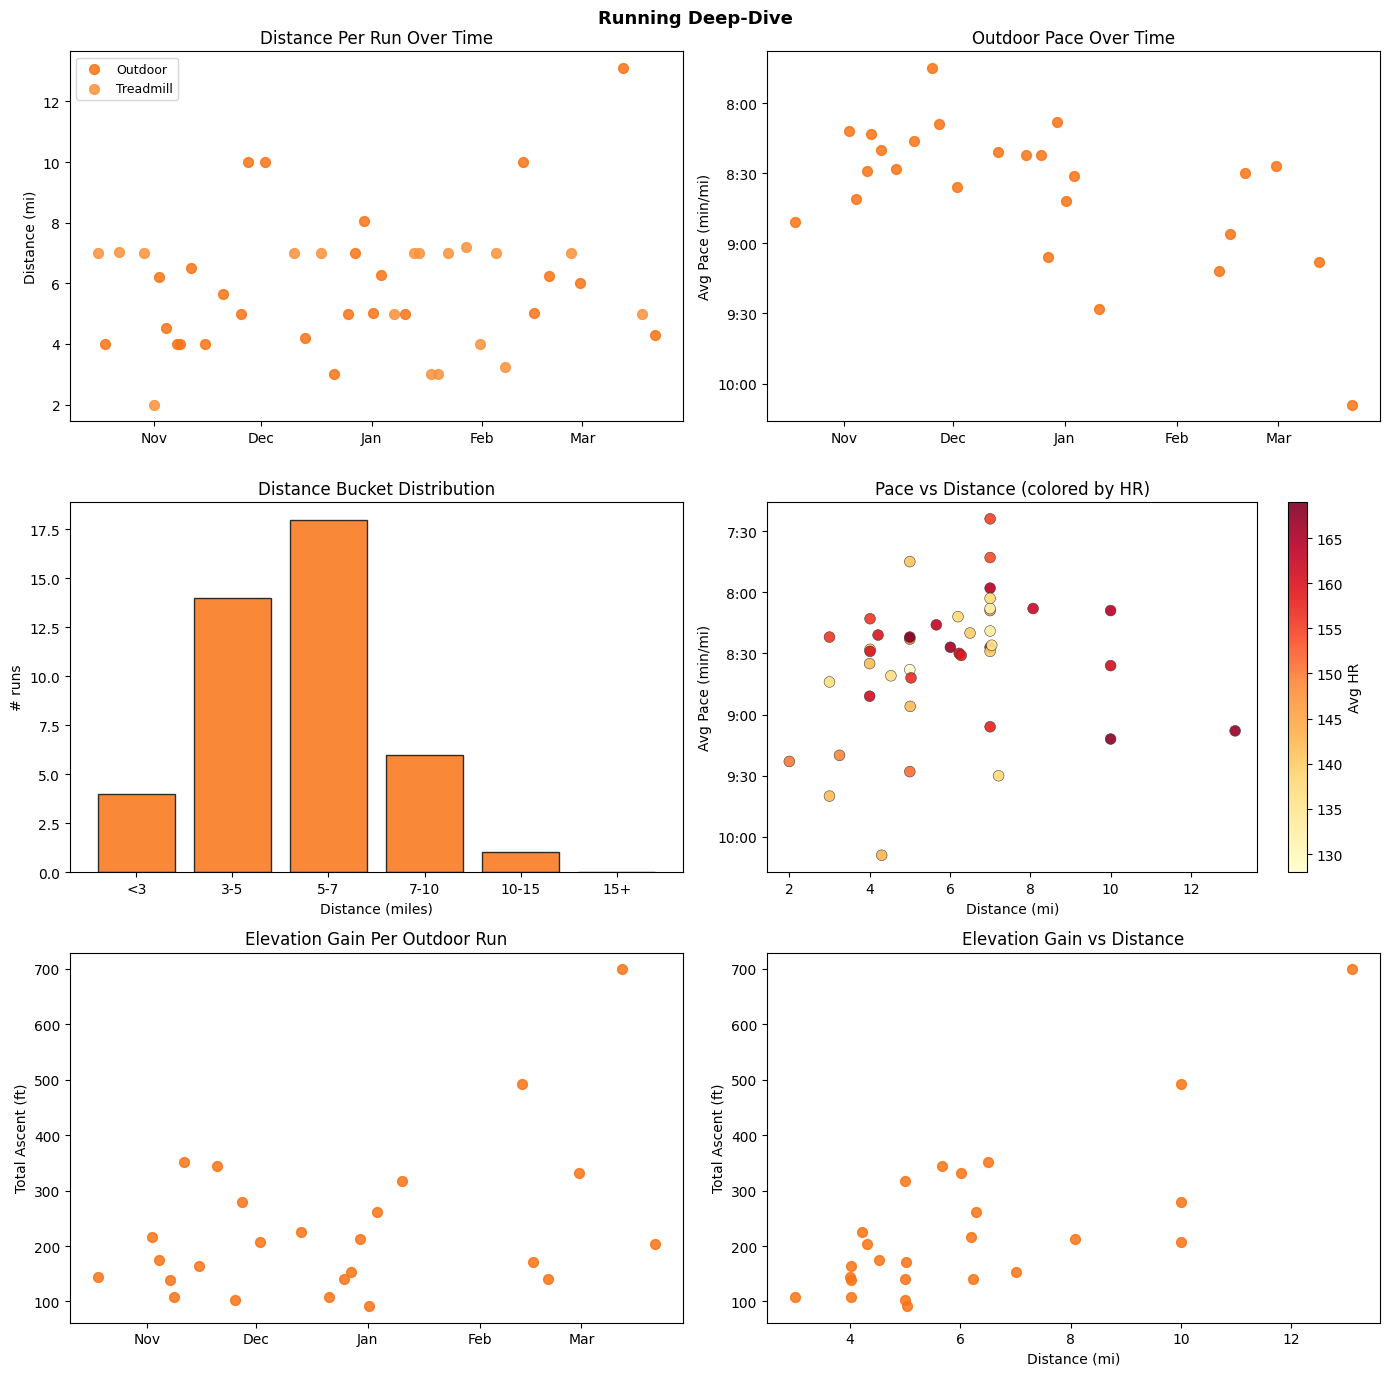

In [85]:
import matplotlib.dates as mdates

runs = df[df['Activity Type'].isin(['Running','Treadmill Running'])].copy()
runs['is_outdoor'] = runs['Activity Type'] == 'Running'

print(f'Total runs: {len(runs)} ({runs["is_outdoor"].sum()} outdoor, {(~runs["is_outdoor"]).sum()} treadmill)')
print(f'Total distance: {runs["Distance"].sum():.1f} miles')
print(f'Longest run: {runs["Distance"].max():.2f} miles')

def sec_to_pace(s):
	if np.isnan(s): return '--'
	m, sec = divmod(int(s), 60)
	return f'{m}:{sec:02d}'

avg_pace = runs['pace_sec_mi'].mean()
best_pace = runs['pace_sec_mi'].min()

print(f'Average pace: {sec_to_pace(avg_pace)} /mi')
print(f'Best avg pace (single run): {sec_to_pace(best_pace)} /mi')

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('Running Deep-Dive', fontsize=13, fontweight='bold')

# Outdoor vs Indoor by distance
ax = axes[0,0]
for is_out, label, color in [(True,'Outdoor','#f97316'),(False,'Treadmill','#fb923c')]:
	sub = runs[runs['is_outdoor']==is_out]
	ax.scatter(sub['Date'], sub['Distance'], color=color, label=label, alpha=0.85, s=50)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_ylabel('Distance (mi)')
ax.set_title('Distance Per Run Over Time')
ax.legend(fontsize=9)

# Outdoor pace over time
ax = axes[0,1]
out = runs[runs['is_outdoor'] & runs['pace_sec_mi'].notna()]
ax.scatter(out['Date'], out['pace_sec_mi']/60, color='#f97316', alpha=0.85, s=50)
ax.invert_yaxis()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v)}:{int((v%1)*60):02d}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_ylabel('Avg Pace (min/mi)')
ax.set_title('Outdoor Pace Over Time')

# Run distribution
ax = axes[1,0]
bins = [0,3,5,7,10,15,25]
labels = ['<3','3-5','5-7','7-10','10-15','15+']
runs['dist_bin'] = pd.cut(runs['Distance'], bins=bins, labels=labels)
dist_counts = runs['dist_bin'].value_counts().reindex(labels)
ax.bar(labels, dist_counts.values, color='#f97316', alpha=0.85, edgecolor='#0f0f0f')
ax.set_xlabel('Distance (miles)')
ax.set_ylabel('# runs')
ax.set_title('Distance Bucket Distribution')

# Pace vs Distance with HR as color — aerobic drift with relation to distance
ax = axes[1,1]
valid = runs[runs['pace_sec_mi'].notna() & runs['Distance'].notna()]
sc = ax.scatter(valid['Distance'], valid['pace_sec_mi']/60,
				c=valid['Avg HR'], cmap='YlOrRd',
				s=60, alpha=0.9, edgecolors='#333', linewidths=0.4)
plt.colorbar(sc, ax=ax, label='Avg HR')
ax.invert_yaxis()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v)}:{int((v%1)*60):02d}'))
ax.set_xlabel('Distance (mi)')
ax.set_ylabel('Avg Pace (min/mi)')
ax.set_title('Pace vs Distance (colored by HR)')

# Clean up empty values
runs['Total Ascent'] = pd.to_numeric(runs['Total Ascent'], errors='coerce')
runs['Total Descent'] = pd.to_numeric(runs['Total Descent'], errors='coerce')
runs['Best Pace'] = pd.to_numeric(runs['Best Pace'], errors='coerce')

# Total ascent per outdoor run over time
ax = axes[2,0]
elev = runs[runs['is_outdoor'] & runs['Total Ascent'].notna()]
ax.scatter(elev['Date'], elev['Total Ascent'], color='#f97316', alpha=0.85, s=50)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_ylabel('Total Ascent (ft)')
ax.set_title('Elevation Gain Per Outdoor Run')

# Ascent vs Distance — how hilly are the longer runs
ax = axes[2,1]
elev_dist = runs[runs['is_outdoor'] & runs['Total Ascent'].notna() & runs['Distance'].notna()]
ax.scatter(elev_dist['Distance'], elev_dist['Total Ascent'], color='#f97316', alpha=0.85, s=50)
ax.set_xlabel('Distance (mi)')
ax.set_ylabel('Total Ascent (ft)')
ax.set_title('Elevation Gain vs Distance')

plt.tight_layout()
plt.show()

### Time of Day Patterns

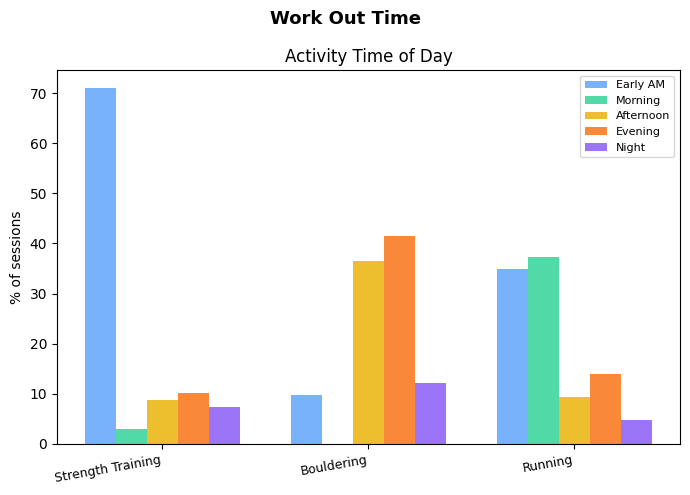

In [75]:
def time_block(h):
	if   h < 6:  return 'Night'
	elif h < 9:  return 'Early AM'
	elif h < 12: return 'Morning'
	elif h < 17: return 'Afternoon'
	elif h < 20: return 'Evening'
	else:        return 'Night'

df['time_block'] = df['hour'].apply(time_block)

blocks = ['Early AM','Morning','Afternoon','Evening','Night']
block_colors = ['#60a5fa','#34d399','#eab308','#f97316','#8b5cf6']
top_types = ['Strength Training','Bouldering','Running']

fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Work Out Time', fontsize=13, fontweight='bold')

x = np.arange(len(top_types))
width = 0.15
for i, (blk, clr) in enumerate(zip(blocks, block_colors)):
	vals = []
	for t in top_types:
		sub = df[df['Activity Type'].str.contains(t)]
		pct = (sub['time_block']==blk).sum() / len(sub) * 100 if len(sub) else 0
		vals.append(pct)
	ax.bar(x + i*width, vals, width, label=blk, color=clr, alpha=0.85)
ax.set_xticks(x + width*2)
ax.set_xticklabels(top_types, rotation=10, ha='right', fontsize=9)
ax.set_ylabel('% of sessions')
ax.set_title('Activity Time of Day')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

### Calorie Breakdown

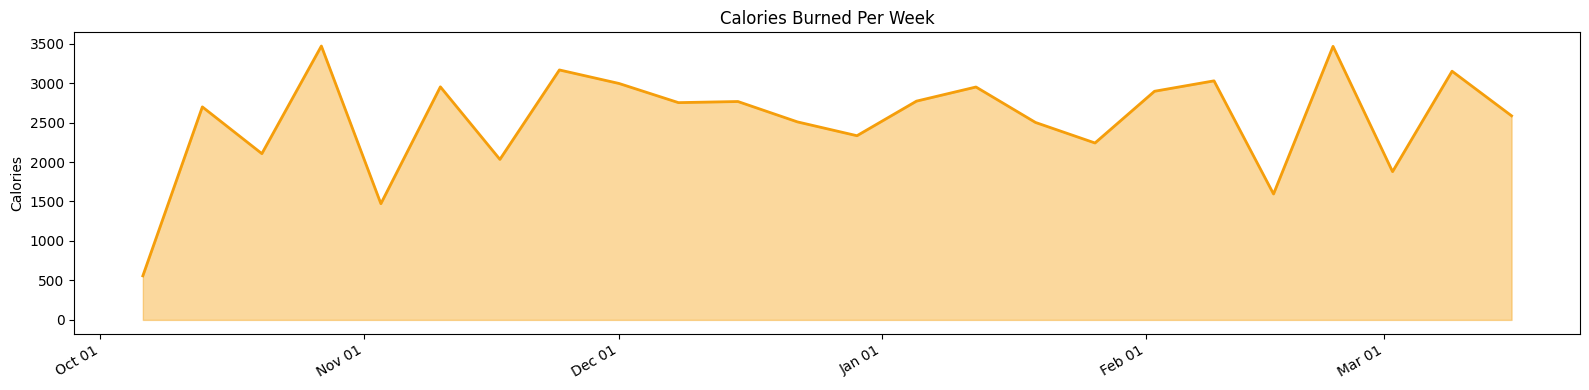

In [81]:
weekly = df.groupby('week').agg(
	total_cal=('Calories','sum')
).reset_index()
weekly['week_start'] = weekly['week'].dt.start_time

fig, ax = plt.subplots(figsize=(16, 4))

ax.fill_between(weekly['week_start'], weekly['total_cal'], alpha=0.4, color='#f59e0b')
ax.plot(weekly['week_start'], weekly['total_cal'], color='#f59e0b', lw=2)
ax.set_ylabel('Calories')
ax.set_title('Calories Burned Per Week')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

I can't imagine anyone else finding this information interesting, but if you made it this far, you are always welcome to join me on my weekend runs or my social climbs on Thursdays.

If you are a potential employer, this is what I can bring to the shareholders :^)